# Notebook 5: Error Analysis

Diagnoses *why* models fail. Three analyses:

**1. 2×2 Error Matrix** — classifies each question as:
```
                        | Gold retrieved | Gold NOT retrieved |
------------------------|----------------|--------------------|
Answer CORRECT          | [A] Both worked| [B] Parametric hit |
Answer INCORRECT        | [C] Reasoning  | [D] Retrieval fail |
                        |     failure    |                    |
```

In [ ]:
# Google Drive
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = '/content/drive/MyDrive/FRAMES'

Mounted at /content/drive


In [ ]:
!pip install matplotlib seaborn pandas -q

In [ ]:
import json, os, re, glob, collections
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load all judge results
RESULTS_DIR = os.path.join(DATA_DIR, 'results')
judge_files = glob.glob(os.path.join(RESULTS_DIR, 'judge_*.json'))

all_results = {}
for path in sorted(judge_files):
    label = os.path.basename(path).replace('judge_', '').replace('.json', '').replace('_', ' ')
    with open(path, encoding='utf-8') as f:
        all_results[label] = json.load(f)
    acc = sum(r['judge_correct'] for r in all_results[label]) / len(all_results[label])
    print(f'{label}: {acc:.3f} accuracy ({len(all_results[label])} questions)')

print(f'\nLoaded {len(all_results)} models')

B1 BERT no-retrieval: 0.005 accuracy (412 questions)
B2 BM25 + BERT: 0.068 accuracy (412 questions)
B3 LLM zero-shot: 0.138 accuracy (412 questions)
B4 LLM few-shot: 0.187 accuracy (412 questions)
C1 Single-hop RAG: 0.265 accuracy (412 questions)
C2 Multi-hop RAG (3hop): 0.294 accuracy (412 questions)

Loaded 6 models


In [ ]:
def title_from_url(url):
    match = re.search(r'/wiki/(.+)', url)
    return match.group(1).replace('_', ' ') if match else url

def gold_retrieved(prediction):
    # Checks if at least one gold article was retrieved
    if 'gold_wiki_links' not in prediction or not prediction.get('retrieved_titles'):
        return False
    gold = set(title_from_url(u).lower() for u in prediction['gold_wiki_links'])
    retrieved = set(t.lower() for t in prediction['retrieved_titles'])
    return bool(gold & retrieved)

## 1. 2×2 Error Matrix

Only applicable to models that do retrieval (C1, C2). B3/B4 (LLM no-retrieval) only have the correct/incorrect dimension.

In [ ]:
def error_matrix(preds):
    A = B = C = D = 0
    for p in preds:
        retrieved = gold_retrieved(p)
        correct = p['judge_correct']
        if retrieved and correct:     A += 1
        elif not retrieved and correct: B += 1
        elif retrieved and not correct: C += 1
        else:                         D += 1
    return {'A_both_worked': A, 'B_parametric': B, 'C_reasoning_fail': C, 'D_retrieval_fail': D}

# Print matrix for retrieval models
for label, preds in all_results.items():
    if not any('retrieved_titles' in p for p in preds[:5]):
        continue
    matrix = error_matrix(preds)
    n = len(preds)
    print(f'\n--- {label} ---')
    print(f'  [A] Retrieved + Correct   (both worked):      {matrix["A_both_worked"]:3d} ({matrix["A_both_worked"]/n:.1%})')
    print(f'  [B] NOT retrieved + Correct (parametric hit): {matrix["B_parametric"]:3d} ({matrix["B_parametric"]/n:.1%})')
    print(f'  [C] Retrieved + INCORRECT (reasoning fail):   {matrix["C_reasoning_fail"]:3d} ({matrix["C_reasoning_fail"]/n:.1%})')
    print(f'  [D] NOT retrieved + INCORRECT (retrieval fail):{matrix["D_retrieval_fail"]:3d} ({matrix["D_retrieval_fail"]/n:.1%})')
    print(f'  --- Interpretation ---')
    total_retrieved = matrix['A_both_worked'] + matrix['C_reasoning_fail']
    if total_retrieved > 0:
        reasoning_fail_rate = matrix['C_reasoning_fail'] / total_retrieved
        print(f'  Reasoning failure rate (given gold retrieved): {reasoning_fail_rate:.1%}')
        print(f'  (FRAMES paper: ~27% even with oracle retrieval)')


--- B1 BERT no-retrieval ---
  [A] Retrieved + Correct   (both worked):        0 (0.0%)
  [B] NOT retrieved + Correct (parametric hit):   2 (0.5%)
  [C] Retrieved + INCORRECT (reasoning fail):     0 (0.0%)
  [D] NOT retrieved + INCORRECT (retrieval fail):410 (99.5%)
  --- Interpretation ---

--- B2 BM25 + BERT ---
  [A] Retrieved + Correct   (both worked):       20 (4.9%)
  [B] NOT retrieved + Correct (parametric hit):   8 (1.9%)
  [C] Retrieved + INCORRECT (reasoning fail):   296 (71.8%)
  [D] NOT retrieved + INCORRECT (retrieval fail): 88 (21.4%)
  --- Interpretation ---
  Reasoning failure rate (given gold retrieved): 93.7%
  (FRAMES paper: ~27% even with oracle retrieval)

--- B3 LLM zero-shot ---
  [A] Retrieved + Correct   (both worked):        0 (0.0%)
  [B] NOT retrieved + Correct (parametric hit):  57 (13.8%)
  [C] Retrieved + INCORRECT (reasoning fail):     0 (0.0%)
  [D] NOT retrieved + INCORRECT (retrieval fail):355 (86.2%)
  --- Interpretation ---

--- B4 LLM few-shot ---

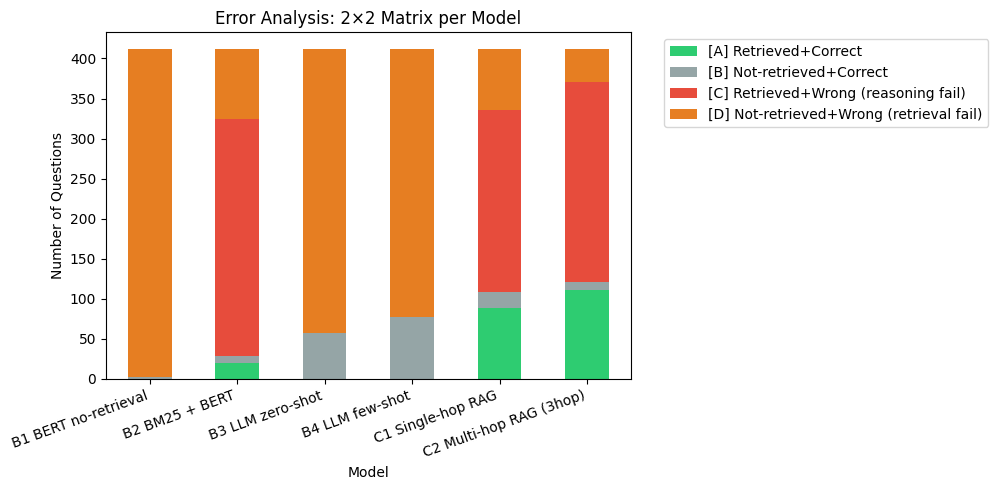

Saved error_matrix.png


In [ ]:
# Plot 2x2 matrix
retrieval_models = {l: p for l, p in all_results.items()
                    if any('retrieved_titles' in r for r in p[:5])}

if retrieval_models:
    labels = list(retrieval_models.keys())
    matrix_data = [error_matrix(retrieval_models[l]) for l in labels]

    df = pd.DataFrame(matrix_data, index=labels)

    ax = df.plot(kind='bar', stacked=True, figsize=(10, 5),
                 color=['#2ecc71', '#95a5a6', '#e74c3c', '#e67e22'])
    plt.title('Error Analysis: 2×2 Matrix per Model')
    plt.xlabel('Model')
    plt.ylabel('Number of Questions')
    plt.xticks(rotation=20, ha='right')
    plt.legend(['[A] Retrieved+Correct', '[B] Not-retrieved+Correct',
                '[C] Retrieved+Wrong (reasoning fail)', '[D] Not-retrieved+Wrong (retrieval fail)'],
               bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(DATA_DIR, 'results', 'error_matrix.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved error_matrix.png')

## 2. Accuracy by Reasoning Type

Expected pattern (from FRAMES paper):
- Multiple Constraints: best performance
- Numerical / Tabular / Post-Processing: worst — even with oracle retrieval

In [ ]:
def accuracy_by_type(preds):
      by_type = collections.defaultdict(list)
      for p in preds:
          rtypes = p.get('reasoning_types') or ''
          if rtypes:
              types = [t.strip() for t in rtypes.split('|')]
          else:
              types = ['Unknown']
          for rtype in types:
              by_type[rtype].append(p['judge_correct'])
      return {t: (sum(v)/len(v), len(v)) for t, v in by_type.items()}

all_types = set()
type_accs = {}
for label, preds in all_results.items():
    accs = accuracy_by_type(preds)
    type_accs[label] = accs
    all_types.update(accs.keys())

all_types = sorted(all_types)

header = f'{"Model":<32}  ' + '  '.join(f'{t[:12]:>12}' for t in all_types)
print(header)
print('-' * len(header))
for label, accs in type_accs.items():
    row = f'{label[:32]:<32}'
    for t in all_types:
        if t in accs:
            row += f'  {accs[t][0]:>12.3f}'
        else:
            row += f'  {"N/A":>12}'
    print(row)

Model                             Multiple con  Numerical re  Post process  Tabular reas  Temporal rea
------------------------------------------------------------------------------------------------------
B1 BERT no-retrieval                     0.004         0.007         0.000         0.009         0.000
B2 BM25 + BERT                           0.081         0.027         0.036         0.068         0.029
B3 LLM zero-shot                         0.136         0.108         0.073         0.120         0.130
B4 LLM few-shot                          0.199         0.108         0.036         0.145         0.188
C1 Single-hop RAG                        0.265         0.176         0.164         0.188         0.246
C2 Multi-hop RAG (3hop)                  0.309         0.223         0.200         0.222         0.261


In [ ]:
sample = next(iter(all_results.values()))[0]
print(list(sample.keys()))
print('reasoning_types:', sample.get('reasoning_types'))

['id', 'question', 'gold_answer', 'predicted', 'score', 'reasoning_types', 'n_gold_articles', 'gold_wiki_links', 'retrieved_titles', 'judge_correct']
reasoning_types: Numerical reasoning | Multiple constraints | Temporal reasoning


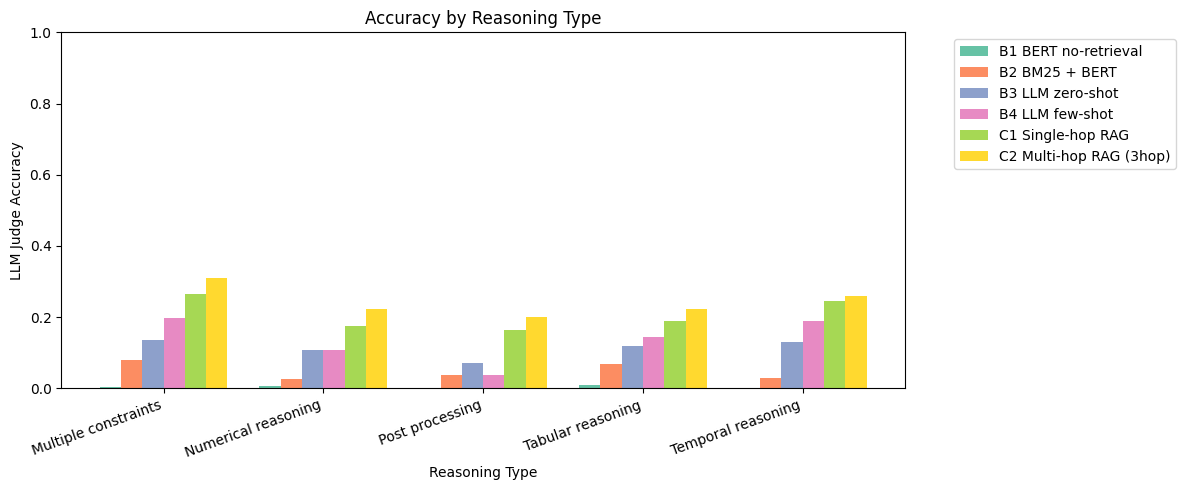

Saved accuracy_by_reasoning_type.png


In [ ]:
# Plot: accuracy by reasoning type for each model
fig, ax = plt.subplots(figsize=(12, 5))

x = range(len(all_types))
width = 0.8 / max(len(all_results), 1)
colors = plt.cm.Set2.colors

for i, (label, accs) in enumerate(type_accs.items()):
    values = [accs.get(t, (0, 0))[0] for t in all_types]
    offset = (i - len(all_results)/2 + 0.5) * width
    ax.bar([xi + offset for xi in x], values, width=width, label=label, color=colors[i % len(colors)])

ax.set_xlabel('Reasoning Type')
ax.set_ylabel('LLM Judge Accuracy')
ax.set_title('Accuracy by Reasoning Type')
ax.set_xticks(list(x))
ax.set_xticklabels(all_types, rotation=20, ha='right')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'results', 'accuracy_by_reasoning_type.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved accuracy_by_reasoning_type.png')

## 3. Accuracy by Number of Required Articles

Tests positional bias and context length effects. Expected: performance degrades as more articles are needed (Liu et al. "Lost in the Middle" effect).

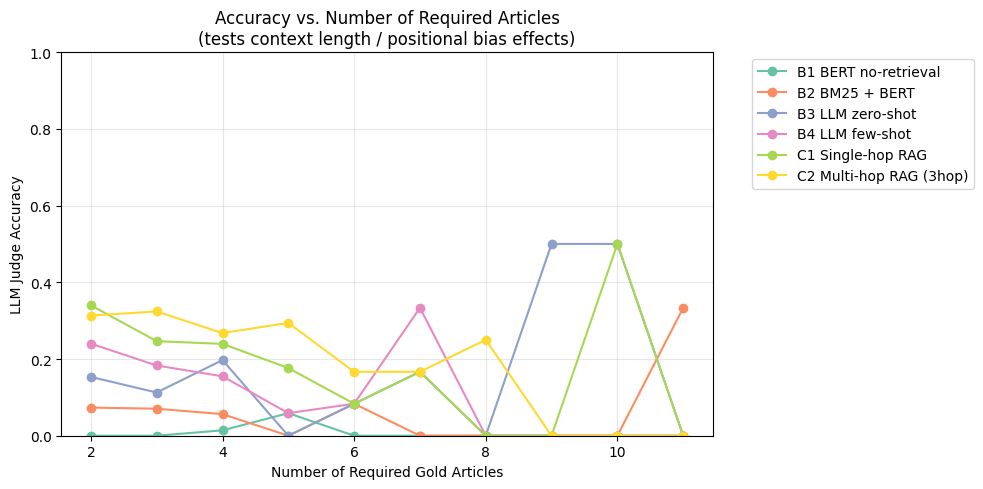

Saved accuracy_by_n_articles.png


In [ ]:
def accuracy_by_n_articles(preds):
    by_n = collections.defaultdict(list)
    for p in preds:
        n = p.get('n_gold_articles', len(p.get('gold_wiki_links', [])))
        by_n[n].append(p['judge_correct'])
    return {n: (sum(v)/len(v), len(v)) for n, v in sorted(by_n.items())}

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.Set2.colors

for i, (label, preds) in enumerate(all_results.items()):
    accs = accuracy_by_n_articles(preds)
    ns = sorted(accs.keys())
    vals = [accs[n][0] for n in ns]
    counts = [accs[n][1] for n in ns]
    ax.plot(ns, vals, marker='o', label=label, color=colors[i % len(colors)])

ax.set_xlabel('Number of Required Gold Articles')
ax.set_ylabel('LLM Judge Accuracy')
ax.set_title('Accuracy vs. Number of Required Articles\n(tests context length / positional bias effects)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(0, 1.0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'results', 'accuracy_by_n_articles.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved accuracy_by_n_articles.png')

In [ ]:
for label, preds in all_results.items():
      accs = accuracy_by_n_articles(preds)
      print(f'{label}:  ' + '  '.join(f'n={n}: {a:.3f}(cnt={c})' for n, (a, c) in sorted(accs.items())))

B1 BERT no-retrieval:  n=2: 0.000(cnt=150)  n=3: 0.000(cnt=142)  n=4: 0.014(cnt=71)  n=5: 0.059(cnt=17)  n=6: 0.000(cnt=12)  n=7: 0.000(cnt=6)  n=8: 0.000(cnt=4)  n=9: 0.000(cnt=2)  n=10: 0.000(cnt=2)  n=11: 0.000(cnt=6)
B2 BM25 + BERT:  n=2: 0.073(cnt=150)  n=3: 0.070(cnt=142)  n=4: 0.056(cnt=71)  n=5: 0.000(cnt=17)  n=6: 0.083(cnt=12)  n=7: 0.000(cnt=6)  n=8: 0.000(cnt=4)  n=9: 0.000(cnt=2)  n=10: 0.000(cnt=2)  n=11: 0.333(cnt=6)
B3 LLM zero-shot:  n=2: 0.153(cnt=150)  n=3: 0.113(cnt=142)  n=4: 0.197(cnt=71)  n=5: 0.000(cnt=17)  n=6: 0.083(cnt=12)  n=7: 0.167(cnt=6)  n=8: 0.000(cnt=4)  n=9: 0.500(cnt=2)  n=10: 0.500(cnt=2)  n=11: 0.000(cnt=6)
B4 LLM few-shot:  n=2: 0.240(cnt=150)  n=3: 0.183(cnt=142)  n=4: 0.155(cnt=71)  n=5: 0.059(cnt=17)  n=6: 0.083(cnt=12)  n=7: 0.333(cnt=6)  n=8: 0.000(cnt=4)  n=9: 0.000(cnt=2)  n=10: 0.000(cnt=2)  n=11: 0.000(cnt=6)
C1 Single-hop RAG:  n=2: 0.340(cnt=150)  n=3: 0.246(cnt=142)  n=4: 0.239(cnt=71)  n=5: 0.176(cnt=17)  n=6: 0.083(cnt=12)  n=7: 0.16

In [ ]:
print('=' * 60)
print('KEY NUMBERS FOR WRITE-UP')
print('=' * 60)

for label, preds in all_results.items():
    n = len(preds)
    acc = sum(p['judge_correct'] for p in preds) / n
    print(f'\n{label}')
    print(f'  Overall LLM-judge accuracy: {acc:.3f}')

    accs = accuracy_by_type(preds)
    for rtype, (a, cnt) in sorted(accs.items(), key=lambda x: -x[1][0]):
        print(f'  {rtype:<30}: {a:.3f}  (n={cnt})')

print('\n' + '=' * 60)
print('All error analysis plots saved to results/')

KEY NUMBERS FOR WRITE-UP

B1 BERT no-retrieval
  Overall LLM-judge accuracy: 0.005
  Tabular reasoning             : 0.009  (n=117)
  Numerical reasoning           : 0.007  (n=148)
  Multiple constraints          : 0.004  (n=272)
  Temporal reasoning            : 0.000  (n=138)
  Post processing               : 0.000  (n=55)

B2 BM25 + BERT
  Overall LLM-judge accuracy: 0.068
  Multiple constraints          : 0.081  (n=272)
  Tabular reasoning             : 0.068  (n=117)
  Post processing               : 0.036  (n=55)
  Temporal reasoning            : 0.029  (n=138)
  Numerical reasoning           : 0.027  (n=148)

B3 LLM zero-shot
  Overall LLM-judge accuracy: 0.138
  Multiple constraints          : 0.136  (n=272)
  Temporal reasoning            : 0.130  (n=138)
  Tabular reasoning             : 0.120  (n=117)
  Numerical reasoning           : 0.108  (n=148)
  Post processing               : 0.073  (n=55)

B4 LLM few-shot
  Overall LLM-judge accuracy: 0.187
  Multiple constraints    